# CS/TVM asymmetric workflow from fitted parameters


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_DIR = Path("/Users/dajuarez4/Documents/QuarkMatt/Quarkyionic-Matter-Codes/QvdQ_isos_assym")
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from asymmetric_cs_tvm_workflow import (
    DEFAULT_TARGET_L0,
    DEFAULT_TARGET_S0,
    MP,
    RHO0,
    build_eos_objects,
    default_density_grid,
    default_rhob_list,
    default_y_values,
    fit_parameter_table,
    fitted_parameters_dict,
    published_comparison,
    save_fixed_y_tables,
)

pd.set_option("display.precision", 6)

OUTPUT_DIR = NOTEBOOK_DIR / "fit_driven_outputs"

# Keep these moderate by default so the notebook is runnable.
# Increase them later if you want a denser final production run.
PARAMETER_DENSITY_GRID = default_density_grid(n_points=51)
BETA_RHOB_LIST = default_rhob_list(n_points=40)
FIXED_Y_RHOB_LIST = default_rhob_list(n_points=80)
Y_VALUES = default_y_values()

EOS_NINT = 120
BETA_Y_SCAN = 40
FQ_MIN = 1.0e-3
FQ_MAX = 1.0

OUTPUT_DIR


PosixPath('/Users/dajuarez4/Documents/QuarkMatt/Quarkyionic-Matter-Codes/QvdQ_isos_assym/fit_driven_outputs')

## Step 1: fit the asymmetric parameters


In [2]:
fit_df = fit_parameter_table(
    target_s0=DEFAULT_TARGET_S0,
    target_l0=DEFAULT_TARGET_L0,
    density_grid=PARAMETER_DENSITY_GRID,
)
comparison_df = published_comparison(fit_df, density_grid=PARAMETER_DENSITY_GRID)
fitted_parameters = fitted_parameters_dict(fit_df)

display(fit_df[["model", "branch", "an", "bn", "apn", "bpn", "S0", "L0"]])

display(
    comparison_df[[
        "model", "branch",
        "d_an", "d_bn", "d_apn", "d_bpn",
        "S0", "published_S0", "L0", "published_L0",
    ]]
)

fitted_parameters


,model,branch,an,bn,apn,bpn,S0,L0
0,cs,eq,37.110193,579.170000,53.419807,579.170000,32.5,121.910973
1,cs,neq,26.743127,386.576614,63.786873,771.763386,32.5,58.900000
2,tvm,eq,37.514082,560.080000,53.535918,560.080000,32.5,121.833999
3,tvm,neq,26.587834,366.270354,64.462166,753.889646,32.5,58.900000


,model,branch,d_an,d_bn,d_apn,d_bpn,S0,published_S0,L0,published_L0
0,cs,eq,0.180193,0.000000,-0.180193,0.000000,32.5,32.721638,121.910973,122.575887
1,cs,neq,0.208127,2.788614,-0.212127,-2.876614,32.5,32.605715,58.900000,58.581644
2,tvm,eq,0.184082,0.000000,-0.184082,0.000000,32.5,32.726421,121.833999,122.513263
3,tvm,neq,-0.192166,2.550354,-0.207834,-2.510354,32.5,32.366063,58.900000,57.918814


{'cs': {'eq': {'an': 37.11019346867113,
   'bn': 579.17,
   'apn': 53.419806531328874,
   'bpn': 579.17},
  'neq': {'an': 26.743127310681484,
   'bn': 386.57661402582437,
   'apn': 63.786872689318514,
   'bpn': 771.7633859741755}},
 'tvm': {'eq': {'an': 37.51408212918287,
   'bn': 560.08,
   'apn': 53.53591787081713,
   'bpn': 560.08},
  'neq': {'an': 26.587834406514624,
   'bn': 366.27035445993226,
   'apn': 64.46216559348537,
   'bpn': 753.8896455400678}}}

## Step 2: build the quarkyonic asymmetric EOS objects

These are the objects used for both the beta-equilibrated run and the fixed-`y` sweeps.


In [3]:
eos_map = build_eos_objects(fitted_parameters, nint=EOS_NINT)
list(eos_map.keys())


['cs', 'tvm']

## Step 3: beta equilibrium + charge neutrality


In [4]:
beta_results = {}
beta_summary_rows = []

for model, branches in eos_map.items():
    for branch, eos in branches.items():
        key = f"{model}_{branch}"
        df = eos.beta_equilibrium_profile(
            BETA_RHOB_LIST,
            fq_min=FQ_MIN,
            fq_max=FQ_MAX,
            tol=1.0e-6,
            y_scan=BETA_Y_SCAN,
        )
        beta_results[key] = df

        rho0_idx = (df["rhob"] - RHO0).abs().idxmin()
        beta_summary_rows.append(
            {
                "model": model,
                "branch": branch,
                "fq_at_rho0": df.loc[rho0_idx, "fq_star"],
                "y_at_rho0": df.loc[rho0_idx, "y_star"],
                "mu_e_at_rho0": df.loc[rho0_idx, "mu_e"],
                "vs2_max": df["vs2"].max(),
            }
        )

beta_summary_df = pd.DataFrame(beta_summary_rows)
display(beta_summary_df)


,model,branch,fq_at_rho0,y_at_rho0,mu_e_at_rho0,vs2_max
0,cs,eq,0.001,0.055158,0.122323,0.744191
1,cs,neq,0.001,0.057054,0.123361,0.689951
2,tvm,eq,0.001,0.055183,0.122337,0.718587
3,tvm,neq,0.001,0.057325,0.123507,0.662492


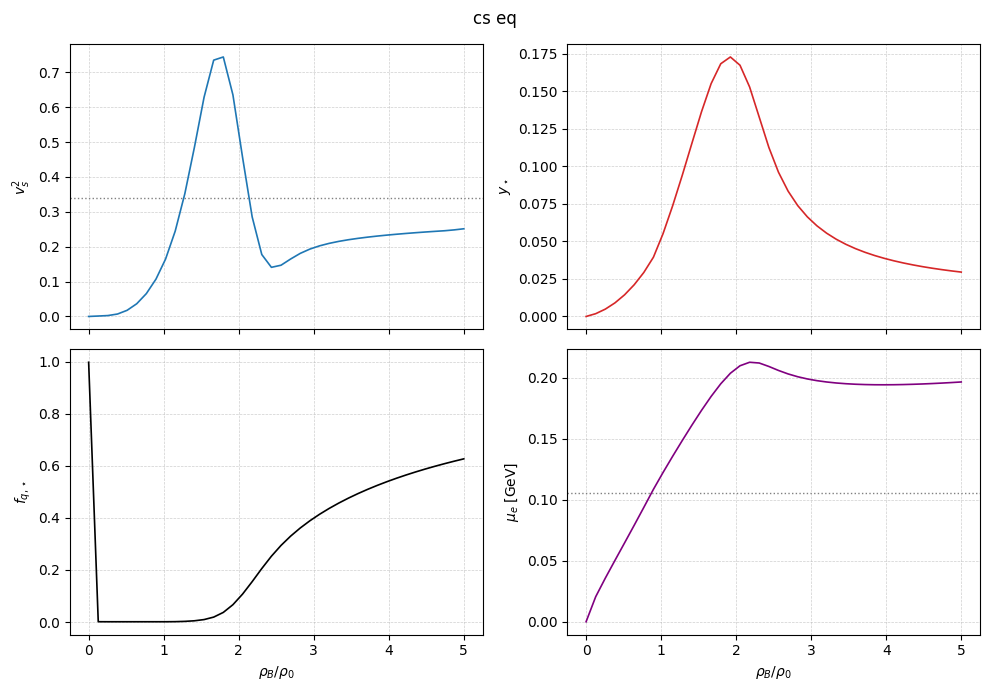

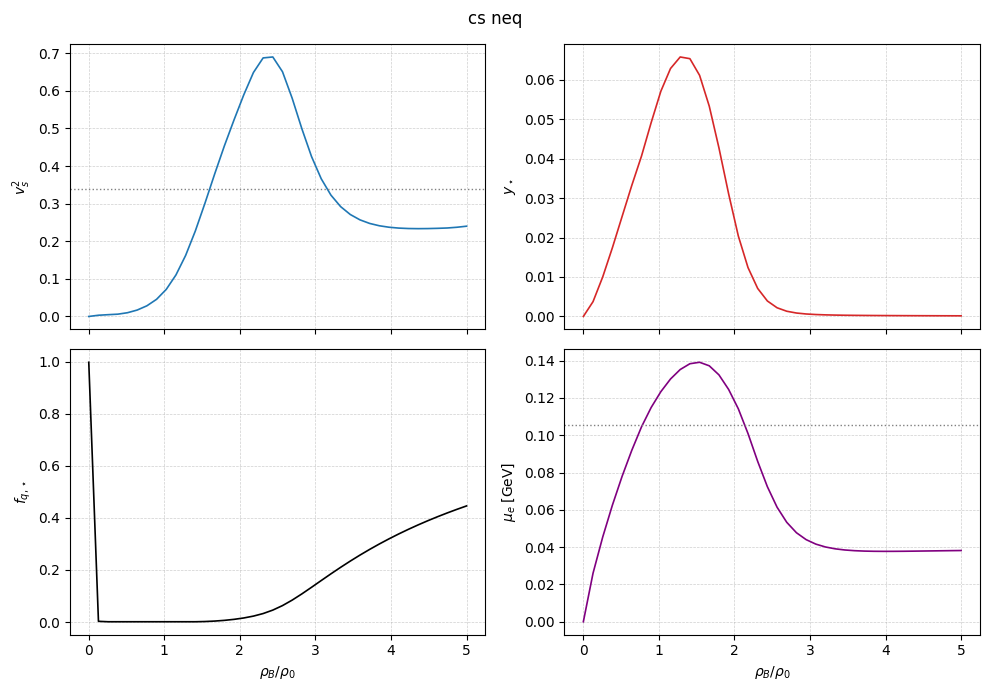

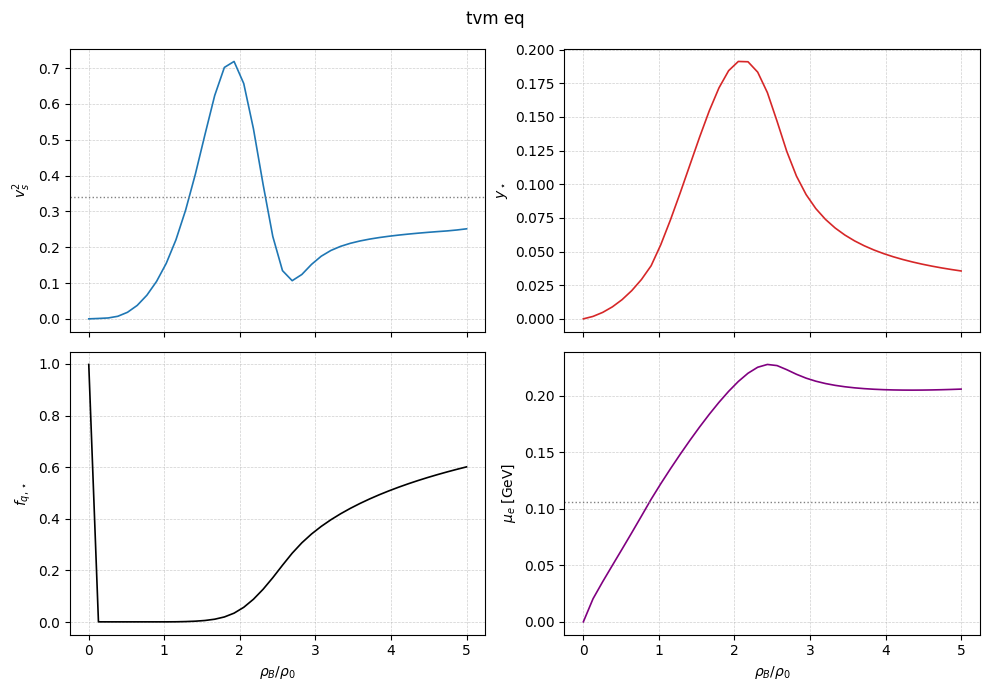

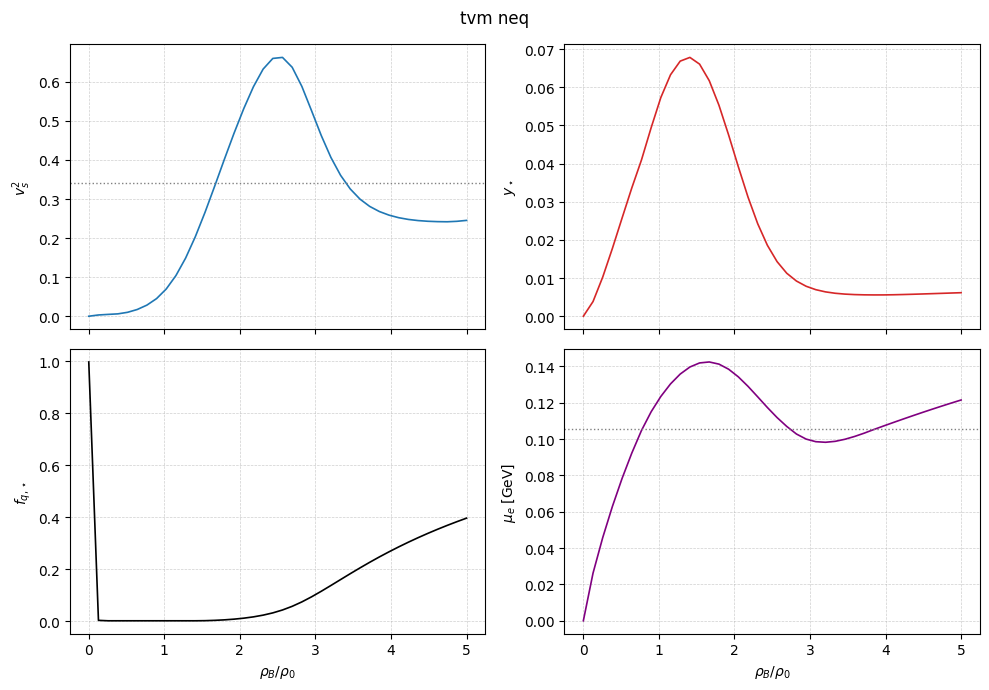

In [5]:
for key, df in beta_results.items():
    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
    fig.suptitle(key.replace("_", " "))

    axes[0, 0].plot(df["rho_over_rho0"], df["vs2"], color="tab:blue", lw=1.2)
    axes[0, 0].axhline(0.34, color="0.5", ls=":", lw=1.0)
    axes[0, 0].set_ylabel(r"$v_s^2$")

    axes[0, 1].plot(df["rho_over_rho0"], df["y_star"], color="tab:red", lw=1.2)
    axes[0, 1].set_ylabel(r"$y_\star$")

    axes[1, 0].plot(df["rho_over_rho0"], df["fq_star"], color="black", lw=1.2)
    axes[1, 0].set_xlabel(r"$\rho_B/\rho_0$")
    axes[1, 0].set_ylabel(r"$f_{q,\star}$")

    axes[1, 1].plot(df["rho_over_rho0"], df["mu_e"], color="purple", lw=1.2)
    axes[1, 1].axhline(0.10566, color="0.5", ls=":", lw=1.0)
    axes[1, 1].set_xlabel(r"$\rho_B/\rho_0$")
    axes[1, 1].set_ylabel(r"$\mu_e$ [GeV]")

    for ax in axes.ravel():
        ax.grid(True, ls="--", lw=0.5, alpha=0.6)

    plt.tight_layout()
    plt.show()


## Step 4: fixed-`y` sweeps and `energy_vs_pressure` tables

The next cell reproduces the fixed-`y` sweeps in the spirit of `QM-isos-4Models.ipynb`, but saves everything into `fit_driven_outputs/`.


In [6]:
fixed_y_results = {}
written_files = []

for model, branches in eos_map.items():
    for branch, eos in branches.items():
        key = f"{model}_{branch}"
        profile_map = {}
        for y in Y_VALUES:
            profile_map[y] = eos.fixed_y_profile(
                FIXED_Y_RHOB_LIST,
                y=y,
                fq_min=FQ_MIN,
                fq_max=FQ_MAX,
                tol=1.0e-6,
            )
        fixed_y_results[key] = profile_map
        written_files.extend(save_fixed_y_tables(profile_map, OUTPUT_DIR, model, branch))

print(f"Wrote {len(written_files)} tables to {OUTPUT_DIR}")
written_files[:8]


Wrote 24 tables to /Users/dajuarez4/Documents/QuarkMatt/Quarkyionic-Matter-Codes/QvdQ_isos_assym/fit_driven_outputs


[PosixPath('/Users/dajuarez4/Documents/QuarkMatt/Quarkyionic-Matter-Codes/QvdQ_isos_assym/fit_driven_outputs/energy_vs_pressure_cs_eq_y0.0.dat'),
 PosixPath('/Users/dajuarez4/Documents/QuarkMatt/Quarkyionic-Matter-Codes/QvdQ_isos_assym/fit_driven_outputs/energy_vs_pressure_cs_eq_y0.1.dat'),
 PosixPath('/Users/dajuarez4/Documents/QuarkMatt/Quarkyionic-Matter-Codes/QvdQ_isos_assym/fit_driven_outputs/energy_vs_pressure_cs_eq_y0.2.dat'),
 PosixPath('/Users/dajuarez4/Documents/QuarkMatt/Quarkyionic-Matter-Codes/QvdQ_isos_assym/fit_driven_outputs/energy_vs_pressure_cs_eq_y0.3.dat'),
 PosixPath('/Users/dajuarez4/Documents/QuarkMatt/Quarkyionic-Matter-Codes/QvdQ_isos_assym/fit_driven_outputs/energy_vs_pressure_cs_eq_y0.4.dat'),
 PosixPath('/Users/dajuarez4/Documents/QuarkMatt/Quarkyionic-Matter-Codes/QvdQ_isos_assym/fit_driven_outputs/energy_vs_pressure_cs_eq_y0.5.dat'),
 PosixPath('/Users/dajuarez4/Documents/QuarkMatt/Quarkyionic-Matter-Codes/QvdQ_isos_assym/fit_driven_outputs/energy_vs_press

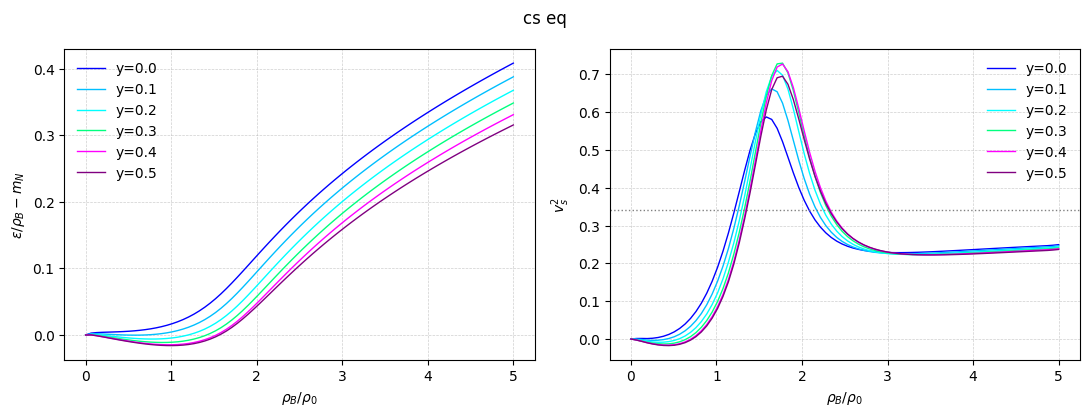

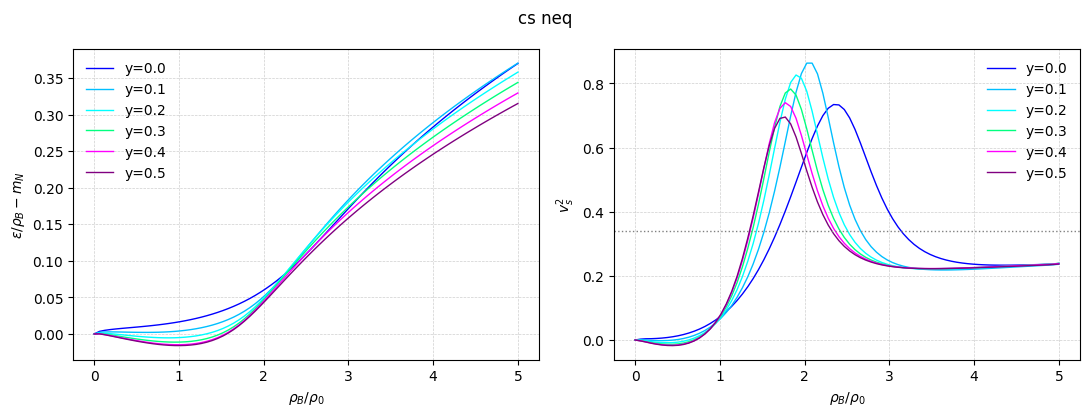

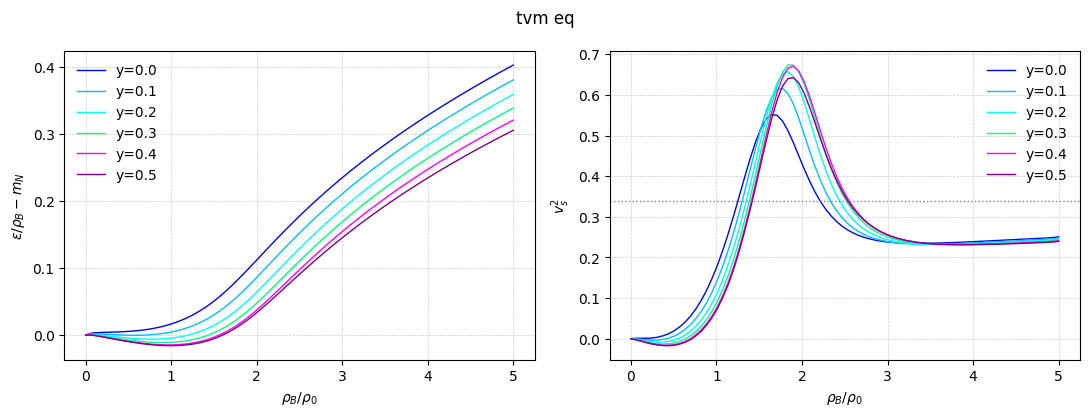

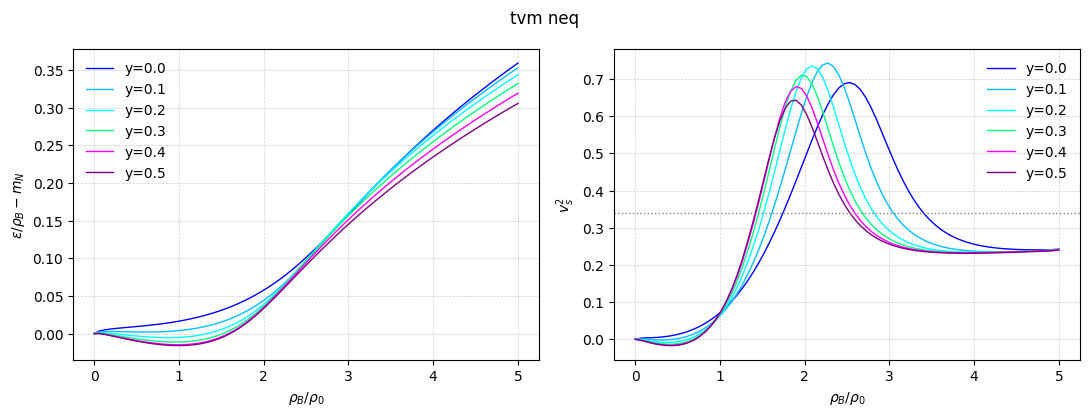

In [7]:
colors = ["blue", "deepskyblue", "cyan", "springgreen", "magenta", "purple"]

for key, profile_map in fixed_y_results.items():
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)
    fig.suptitle(key.replace("_", " "))

    for color, y in zip(colors, Y_VALUES):
        df = profile_map[y]
        axes[0].plot(
            df["rho_over_rho0"],
            df["energy_density"] / df["rhob"] - MP,
            color=color,
            lw=1.0,
            label=f"y={y:.1f}",
        )
        axes[1].plot(df["rho_over_rho0"], df["vs2"], color=color, lw=1.0, label=f"y={y:.1f}")

    axes[0].set_ylabel(r"$\epsilon / \rho_B - m_N$")
    axes[0].set_xlabel(r"$\rho_B/\rho_0$")
    axes[1].set_ylabel(r"$v_s^2$")
    axes[1].set_xlabel(r"$\rho_B/\rho_0$")
    axes[1].axhline(0.34, color="0.5", ls=":", lw=1.0)

    for ax in axes:
        ax.grid(True, ls="--", lw=0.5, alpha=0.6)
        ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()
